This cell rebuilds a single clean master table by combining the decontaminated count data with taxonomy re-parsed from the original BLAST output. It was written to correct a row-alignment error in zotutab_decontam_unstandardized_naming.csv, in which the seven taxonomy columns were shifted up by one row relative to the zOTU IDs and counts, so that each zOTU carried the taxonomy of the sequence below it (6,062 of 6,197 rows matched the next row's lineage rather than their own). That shift had also pushed Zotu198 off the top of the file and left Zotu168 duplicated with two conflicting assignments. The cell therefore takes counts from zotutab_decontam_0p10.csv (6,192 zOTUs × 62 samples, the authoritative post-decontam output from R), and taxonomy from 100225EClee926r-zotus_fa_all_OTU.xlsx (6,412 zOTUs, no duplicates), parsing each semicolon-delimited lineage string into seven ranks using its k__/p__/c__/o__/f__/g__/s__ prefixes. The ANATOMY row was carried over unchanged from the original file, and sample columns were matched between the two sources by normalised suffix, which required folding the letter O to a zero because two Ibex depth cores are spelled IX.2OCM.B and IX.3OCM.A in the count table but IX.20CM.B and IX.30CM.A in the ANATOMY file. The merged table was then sorted numerically by zOTU number and written as zotutab_decontam_master.csv with the ANATOMY row first, the column header row second, and columns ordered as zOTU ID, 62 samples, then the seven taxonomy ranks. No zOTUs were filtered at this stage: all 6,192 were retained, comprising 6,016 prokaryotes with an assigned phylum, 56 eukaryotes (38 Eukaryota, 14 Viridiplantae, 3 Metazoa, 1 Fungi), 116 sequences with no BLAST hit, and 4 classified only to domain level. Sixteen verification checks confirmed that every count cell round-tripped exactly against the input count file, that every taxonomy cell matched the xlsx, that no duplicate zOTU IDs remained, and that each retained category was still present in the output.

In [ ]:
# =====================================================================
# BUILD A CLEAN MASTER TABLE
#
# WHY THIS EXISTS
#   zotutab_decontam_unstandardized_naming.csv has its 7 taxonomy columns
#   shifted UP by one row: each zOTU carries the NEXT row's taxonomy.
#   That shift also pushed Zotu198 off the top of the file and duplicated
#   Zotu168.  The counts and IDs in that file are fine; only the taxonomy
#   is wrong, so this script rebuilds taxonomy from the xlsx instead.
#
# THIS SCRIPT REMOVES NOTHING.
#   Every zOTU in zotutab_decontam_0p10.csv is carried through, including
#   eukaryotes, sequences with no BLAST hit, and sequences classified only
#   to domain level (Phylum == "bacteria").  Those categories are counted
#   and reported so you know what is there, but all of them stay in the
#   output.  Filtering happens in a later step.
#
# INPUTS
#   zotutab_decontam_0p10.csv              counts (authoritative, from R)
#   100225EClee926r-zotus_fa_all_OTU.xlsx  taxonomy (authoritative)
#   zotutab_decontam_unstandardized_naming.csv  ANATOMY row only
#
# OUTPUT
#   zotutab_decontam_master.csv
#     row 1  = ANATOMY
#     row 2  = Zotu | 62 sample columns | Domain..Species
#     row 3+ = one row per zOTU, sorted numerically, no duplicates
# =====================================================================

import pandas as pd
import numpy as np
import csv, os, re

# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
COUNTS_FILE = "/content/zotutab_decontam_0p10.csv"
XLSX_FILE   = "/content/100225EClee926r-zotus.fa.all.OTU.xlsx"
ANAT_FILE   = "/content/zotutab_decontam_unstandardized_naming.csv"
OUT_FILE    = "/content/zotutab_decontam_master.csv"

XLSX_SHEET    = "OTU_Counts"   # sheet holding 'otu name' + 'Taxonomy'
USE_SHORT_NAMES = True         # True  -> MF.4B          (matches old files)
                               # False -> MESQUITE.FLATS.SAND.MF.4B

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
RANK_PREFIX = {"k": "Domain", "p": "Phylum", "c": "Class", "o": "Order",
               "f": "Family", "g": "Genus", "s": "Species"}

print("=" * 70)
print("BUILDING CLEAN MASTER TABLE")
print("=" * 70)


# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
def zotu_number(zid):
    """Integer inside a zOTU ID, used for numeric sorting."""
    m = re.search(r"(\d+)", str(zid))
    return int(m.group(1)) if m else -1


def norm_name(s):
    """Normalise a sample name for matching only.

    Two of the Ibex cores are spelled with a capital letter O instead of a
    zero ('IX.2OCM.B') in the count table but with a zero ('IX.20CM.B') in
    the ANATOMY file.  Folding O -> 0 makes them match.  No real sample
    name contains a genuine letter O, so this is safe."""
    return str(s).upper().replace("O", "0").strip()


def parse_taxonomy(tax_string):
    """Split a lineage string into the 7 ranks.

    Format: 'Species name  ;k__bacteria;p__pseudomonadota;c__...;s__...;'
    Ranks absent from the string come back as an empty string."""
    out = {r: "" for r in TAX_COLS}
    if tax_string is None or (isinstance(tax_string, float) and np.isnan(tax_string)):
        return out
    for part in str(tax_string).split(";"):
        m = re.match(r"^\s*([kpcofgs])__(.*)$", part.strip())
        if m and m.group(1) in RANK_PREFIX:
            out[RANK_PREFIX[m.group(1)]] = m.group(2).strip()
    return out


# ---------------------------------------------------------------------
# STEP 1 — COUNTS (authoritative for which zOTUs and what numbers)
# ---------------------------------------------------------------------
print("\n[1] COUNTS")

counts = pd.read_csv(COUNTS_FILE)
counts = counts.rename(columns={counts.columns[0]: "Zotu"})
counts["Zotu"] = counts["Zotu"].astype(str).str.strip()

count_sample_cols = [c for c in counts.columns if c != "Zotu"]
counts[count_sample_cols] = (counts[count_sample_cols]
                             .apply(pd.to_numeric, errors="coerce").fillna(0))

print(f"  zOTUs:   {len(counts)}")
print(f"  samples: {len(count_sample_cols)}")
print(f"  duplicate IDs: {int(counts['Zotu'].duplicated().sum())}")

if counts["Zotu"].duplicated().any():
    raise ValueError("Count file has duplicate zOTU IDs — stop and inspect.")


# ---------------------------------------------------------------------
# STEP 2 — TAXONOMY FROM THE XLSX
# ---------------------------------------------------------------------
print("\n[2] TAXONOMY FROM XLSX")

xl = pd.read_excel(XLSX_FILE, sheet_name=XLSX_SHEET, engine="openpyxl")
xl.columns = [str(c).strip() for c in xl.columns]

id_col  = xl.columns[0]      # 'otu name'
tax_col = "Taxonomy"
if tax_col not in xl.columns:
    raise ValueError(f"'{tax_col}' column not found. Columns: {xl.columns[:8].tolist()}")

xl[id_col] = xl[id_col].astype(str).str.strip()
xl = xl[xl[id_col].str.match(r"^Zotu\d+$", na=False)].copy()

print(f"  zOTUs in xlsx: {len(xl)}")
print(f"  duplicate IDs: {int(xl[id_col].duplicated().sum())}")
if xl[id_col].duplicated().any():
    raise ValueError("xlsx has duplicate zOTU IDs — stop and inspect.")

parsed = xl[tax_col].apply(parse_taxonomy).apply(pd.Series)
taxonomy = pd.concat([xl[[id_col]].rename(columns={id_col: "Zotu"}), parsed], axis=1)

# how complete is each rank?
print("  rank completeness in xlsx:")
for r in TAX_COLS:
    filled = int((taxonomy[r].astype(str).str.strip() != "").sum())
    print(f"    {r:<9} {filled:>5} / {len(taxonomy)}  ({100*filled/len(taxonomy):.1f}%)")


# ---------------------------------------------------------------------
# STEP 3 — ANATOMY ROW (from the old file; its header row is correct)
# ---------------------------------------------------------------------
print("\n[3] ANATOMY ROW")

with open(ANAT_FILE, "r", newline="") as f:
    reader = csv.reader(f)
    anat_vals = next(reader)
    anat_hdr  = next(reader)

if str(anat_vals[0]).strip().upper() != "ANATOMY":
    raise ValueError("First row of the ANATOMY file does not start with 'ANATOMY'.")

# short sample code -> anatomy label, in the file's original column order
anat_sample_cols = [c for c in anat_hdr[1:] if c not in TAX_COLS]
anat_lookup = {c: a for c, a in zip(anat_hdr, anat_vals)}

print(f"  sample columns in ANATOMY file: {len(anat_sample_cols)}")
labels = sorted({str(anat_lookup[c]).strip() for c in anat_sample_cols})
print(f"  distinct labels: {labels}")


# ---------------------------------------------------------------------
# STEP 4 — MAP COUNT COLUMNS TO SHORT CODES
# The count file uses long names (MESQUITE.FLATS.SAND.MF.4B); the ANATOMY
# file uses short codes (MF.4B).  Match by normalised suffix.
# ---------------------------------------------------------------------
print("\n[4] MATCHING SAMPLE COLUMNS")

long_to_short = {}
for short in anat_sample_cols:
    ns = norm_name(short)
    hits = [c for c in count_sample_cols
            if norm_name(c).endswith(ns)
            and (len(norm_name(c)) == len(ns)
                 or not norm_name(c)[len(norm_name(c)) - len(ns) - 1].isalnum())]
    if len(hits) == 1:
        long_to_short[hits[0]] = short
    elif len(hits) == 0:
        print(f"  WARNING: no count column matches '{short}'")
    else:
        print(f"  WARNING: '{short}' matched {len(hits)} columns: {hits}")

unmatched = [c for c in count_sample_cols if c not in long_to_short]
print(f"  matched: {len(long_to_short)} / {len(count_sample_cols)}")
if unmatched:
    print(f"  WARNING: unmatched count columns: {unmatched}")

# keep the ANATOMY file's column order
ordered_long = [c for c in count_sample_cols if c in long_to_short]
ordered_long.sort(key=lambda c: anat_sample_cols.index(long_to_short[c]))
print(f"  O/0 spelling fixes applied where needed "
      f"(e.g. IX.2OCM.B -> {long_to_short.get('IBEX.SAND.IX.2OCM.B', 'n/a')})")


# ---------------------------------------------------------------------
# STEP 5 — MERGE, SORT, WRITE
# ---------------------------------------------------------------------
print("\n[5] MERGING")

df = counts[["Zotu"] + ordered_long].merge(taxonomy, on="Zotu", how="left")

if len(df) != len(counts):
    raise ValueError("Merge changed the row count — duplicate taxonomy rows.")


# ---------------------------------------------------------------------
# CENSUS — what kinds of zOTU are in here.
# NOTHING below is removed; these are counts only, so you can see the
# composition before deciding what to filter in a later step.
# ---------------------------------------------------------------------
_dom = df["Domain"].fillna("").astype(str).str.strip().str.lower()
_phy = df["Phylum"].fillna("").astype(str).str.strip().str.lower()

EUK_DOMAINS = {"eukaryota", "viridiplantae", "metazoa", "fungi"}
DOMAIN_ONLY = {"bacteria", "archaea"}   # as a PHYLUM value = domain-level only

cat_unassigned = (_dom == "") & (_phy == "")
cat_eukaryote  = _dom.isin(EUK_DOMAINS)
cat_domainonly = (~cat_unassigned) & _phy.isin(DOMAIN_ONLY)
cat_prokaryote = ~(cat_unassigned | cat_eukaryote | cat_domainonly)

print("  category census (all of these are KEPT):")
print(f"    prokaryote, phylum assigned   {int(cat_prokaryote.sum()):>5}")
print(f"    eukaryote                     {int(cat_eukaryote.sum()):>5}")
for d in sorted(EUK_DOMAINS):
    n = int((_dom == d).sum())
    if n:
        print(f"        {d:<24} {n:>5}")
print(f"    unassigned (no BLAST hit)     {int(cat_unassigned.sum()):>5}")
print(f"    domain level only             {int(cat_domainonly.sum()):>5}")
for d in sorted(DOMAIN_ONLY):
    n = int((cat_domainonly & (_phy == d)).sum())
    if n:
        print(f"        Phylum = {d:<19} {n:>5}")
print(f"    {'-' * 34}")
print(f"    TOTAL RETAINED                {len(df):>5}")

_sum = int(cat_prokaryote.sum() + cat_eukaryote.sum()
           + cat_unassigned.sum() + cat_domainonly.sum())
if _sum != len(df):
    raise ValueError(f"Category counts sum to {_sum}, expected {len(df)}.")

# numeric sort: Zotu1, Zotu2, Zotu5 ... not Zotu1, Zotu10, Zotu100
df["_n"] = df["Zotu"].apply(zotu_number)
df = df.sort_values("_n").drop(columns="_n").reset_index(drop=True)

# rename sample columns to short codes if requested
if USE_SHORT_NAMES:
    df = df.rename(columns=long_to_short)
    out_sample_cols = [long_to_short[c] for c in ordered_long]
else:
    out_sample_cols = ordered_long

df = df[["Zotu"] + out_sample_cols + TAX_COLS]

# build the ANATOMY row aligned to the output columns
anatomy_row = ["ANATOMY"]
for c in out_sample_cols:
    key = c if USE_SHORT_NAMES else long_to_short[c]
    anatomy_row.append(anat_lookup.get(key, ""))
anatomy_row += [""] * len(TAX_COLS)

with open(OUT_FILE, "w", newline="") as f:
    csv.writer(f, quoting=csv.QUOTE_MINIMAL).writerow(anatomy_row)
df.to_csv(OUT_FILE, mode="a", index=False)

print(f"\n  wrote {OUT_FILE}")
print(f"  {df.shape[0]} zOTUs x {len(out_sample_cols)} samples + {len(TAX_COLS)} taxonomy columns")


# =====================================================================
# VERIFICATION
# =====================================================================
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

results = []
def check(label, ok, detail=""):
    results.append(bool(ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label}{'  ' + detail if detail else ''}")

raw = pd.read_csv(OUT_FILE, header=None, dtype=str)
v_anat = raw.iloc[0].tolist()
v_hdr  = raw.iloc[1].tolist()
v_data = raw.iloc[2:].copy()
v_data.columns = v_hdr
v_data.reset_index(drop=True, inplace=True)

check("row 1 starts with ANATOMY", str(v_anat[0]).strip().upper() == "ANATOMY")
check("row 2 starts with Zotu",    str(v_hdr[0]).strip() == "Zotu")
check("ANATOMY / header / data widths match",
      len(v_anat) == len(v_hdr) == v_data.shape[1],
      f"({len(v_anat)} / {len(v_hdr)} / {v_data.shape[1]})")
check("taxonomy columns are the last 7", v_hdr[-7:] == TAX_COLS)

ids = v_data["Zotu"].astype(str).str.strip()
check("no duplicate zOTU IDs", not ids.duplicated().any(),
      f"({int(ids.duplicated().sum())} dupes)" if ids.duplicated().any() else "")
check("zOTU count matches the count file", len(v_data) == len(counts),
      f"({len(v_data)} vs {len(counts)})")
check("zOTU ID set matches the count file",
      set(ids) == set(counts["Zotu"]))
check("NOTHING was removed — every input zOTU is present",
      len(v_data) == len(counts) and set(ids) == set(counts["Zotu"]),
      f"({len(v_data)} in, {len(v_data)} out)")
check("eukaryotes retained",
      int(v_data["Domain"].fillna("").str.strip().str.lower()
          .isin(["eukaryota", "viridiplantae", "metazoa", "fungi"]).sum()) > 0,
      f"({int(v_data['Domain'].fillna('').str.strip().str.lower().isin(['eukaryota','viridiplantae','metazoa','fungi']).sum())} present)")
check("unassigned zOTUs retained",
      int((v_data["Domain"].fillna("").str.strip() == "").sum()) > 0,
      f"({int((v_data['Domain'].fillna('').str.strip() == '').sum())} present)")
check("domain-level-only zOTUs retained",
      int(v_data["Phylum"].fillna("").str.strip().str.lower()
          .isin(["bacteria", "archaea"]).sum()) > 0,
      f"({int(v_data['Phylum'].fillna('').str.strip().str.lower().isin(['bacteria','archaea']).sum())} present)")

nums = ids.apply(zotu_number).tolist()
check("sorted numerically", nums == sorted(nums),
      f"first: {ids.head(5).tolist()}")

# counts round-trip exactly
orig = counts.set_index("Zotu")[ordered_long]
orig.columns = out_sample_cols
back = v_data.set_index("Zotu")[out_sample_cols].apply(pd.to_numeric, errors="coerce")
aligned = back.loc[orig.index]
check("every count matches the count file exactly",
      bool((aligned.values == orig.values).all()),
      f"({int((aligned.values != orig.values).sum())} mismatched cells)")

# taxonomy round-trip against the xlsx
tax_ref = taxonomy.set_index("Zotu")
tax_out = v_data.set_index("Zotu")[TAX_COLS].fillna("")
shared = [z for z in tax_out.index if z in tax_ref.index]
bad = sum(1 for z in shared
          for r in TAX_COLS
          if str(tax_out.loc[z, r]).strip().lower()
          != str(tax_ref.loc[z, r]).strip().lower())
check("every taxonomy cell matches the xlsx", bad == 0, f"({bad} mismatched cells)")

check("no blank sample column",
      not [c for c in out_sample_cols if "blank" in str(c).lower()])
check("62 samples present", len(out_sample_cols) == 62,
      f"({len(out_sample_cols)})")

n_ok, n_all = sum(results), len(results)
print("\n" + "=" * 70)
print(f"{n_ok} / {n_all} checks passed"
      f"{'  — ALL CLEAR' if n_ok == n_all else '  — REVIEW ABOVE'}")
print("=" * 70)


# =====================================================================
# AUDIT — what was wrong with the old file
# =====================================================================
print("\n" + "=" * 70)
print("AUDIT OF zotutab_decontam_unstandardized_naming.csv")
print("=" * 70)

old_raw = pd.read_csv(ANAT_FILE, header=None, dtype=str)
old = old_raw.iloc[2:].copy()
old.columns = old_raw.iloc[1].tolist()
old = old[old.iloc[:, 0].notna() & (old.iloc[:, 0].astype(str).str.strip() != "")]
old_ids = old.iloc[:, 0].astype(str).str.strip().tolist()

tax_ref_l = {z: {r: str(tax_ref.loc[z, r]).strip().lower() for r in TAX_COLS}
             for z in tax_ref.index}

match_self, match_next = 0, 0
for i, zid in enumerate(old_ids):
    row = {r: str(old.iloc[i][r]).strip().lower() if pd.notna(old.iloc[i][r]) else ""
           for r in TAX_COLS}
    if zid in tax_ref_l and all(row[r] == tax_ref_l[zid][r] for r in TAX_COLS):
        match_self += 1
    if i + 1 < len(old_ids):
        nxt = old_ids[i + 1]
        if nxt in tax_ref_l and all(row[r] == tax_ref_l[nxt][r] for r in TAX_COLS):
            match_next += 1

print(f"  rows: {len(old_ids)}")
print(f"  taxonomy matching its OWN zOTU  : {match_self}")
print(f"  taxonomy matching the NEXT row  : {match_next}  <- the off-by-one shift")
print(f"  duplicate IDs: {sorted(set(z for z in old_ids if old_ids.count(z) > 1))}")
print(f"  in counts but missing from old file: {sorted(set(counts['Zotu']) - set(old_ids))}")
print(f"  in old file but not in counts (blank-only, dropped by R): "
      f"{sorted(set(old_ids) - set(counts['Zotu']))}")

BUILDING CLEAN MASTER TABLE

[1] COUNTS
  zOTUs:   6192
  samples: 62
  duplicate IDs: 0

[2] TAXONOMY FROM XLSX
  zOTUs in xlsx: 6412
  duplicate IDs: 0
  rank completeness in xlsx:
    Domain     6291 / 6412  (98.1%)
    Phylum     6291 / 6412  (98.1%)
    Class      6291 / 6412  (98.1%)
    Order      6291 / 6412  (98.1%)
    Family     6291 / 6412  (98.1%)
    Genus      6291 / 6412  (98.1%)
    Species    6291 / 6412  (98.1%)

[3] ANATOMY ROW
  sample columns in ANATOMY file: 62
  distinct labels: ['Interdune', 'Interdune, Depth', 'Lee', 'Lee, Star', 'Stoss', 'Stoss, Crest', 'Stoss, Depth', 'Stoss, Star']

[4] MATCHING SAMPLE COLUMNS
  matched: 62 / 62
  O/0 spelling fixes applied where needed (e.g. IX.2OCM.B -> IX.20CM.B)

[5] MERGING
  category census (all of these are KEPT):
    prokaryote, phylum assigned    6016
    eukaryote                        56
        eukaryota                   38
        fungi                        1
        metazoa                      3
        v

In [ ]:
# =====================================================================
# CELL 1 — REMOVE EUKARYOTES
#
# IN   zotutab_decontam_master.csv        6192 zOTUs
# OUT  zotutab_decontam_eukaryotesremoved.csv         6136 zOTUs (expected)
#      removed_eukaryotes.csv             the 56 removed, for your records
#
# Removes zOTUs whose Domain is eukaryota, viridiplantae, metazoa or fungi.
# A phylum-level list is also checked as a safety net, in case a sequence
# has a eukaryotic phylum but a blank or odd domain.
# Nothing else is touched: unassigned zOTUs and domain-level-only zOTUs
# are left in and handled in Cell 2.
# =====================================================================

import pandas as pd
import csv, os

IN_FILE   = "/content/zotutab_decontam_master.csv"
OUT_FILE  = "/content/zotutab_decontam_eukaryotesremoved.csv"
LOG_FILE  = "/content/removed_eukaryotes.csv"

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

EUK_DOMAINS = ["eukaryota", "viridiplantae", "metazoa", "fungi"]

# Safety net only — these should already be caught by the domain rule.
EUK_PHYLA = [
    "bacillariophyta", "basidiomycota", "ascomycota", "chlorophyta",
    "chordata", "ciliophora", "discosea", "eukaryota",
    "eustigmatophyceae", "oomycota", "phaeophyceae", "rhodophyta",
    "streptophyta", "tubulinea", "choanoflagellatea",
]

print("=" * 70)
print("CELL 1 — REMOVING EUKARYOTES")
print("=" * 70)


# ---------------------------------------------------------------------
# LOAD  (row 0 = ANATOMY, row 1 = header, row 2+ = data)
# ---------------------------------------------------------------------
raw = pd.read_csv(IN_FILE, header=None, dtype=str)
if str(raw.iloc[0, 0]).strip().upper() != "ANATOMY":
    raise ValueError("Row 1 of the input is not the ANATOMY row.")

anatomy = raw.iloc[0].tolist()
header  = raw.iloc[1].tolist()
df      = raw.iloc[2:].copy()
df.columns = header
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in header[1:] if c not in TAX_COLS]
n_in = len(df)

print(f"\n  loaded: {n_in} zOTUs x {len(sample_cols)} samples")


# ---------------------------------------------------------------------
# IDENTIFY EUKARYOTES
# ---------------------------------------------------------------------
dom = df["Domain"].fillna("").astype(str).str.strip().str.lower()
phy = df["Phylum"].fillna("").astype(str).str.strip().str.lower()

by_domain = dom.isin(EUK_DOMAINS)
by_phylum = phy.isin(EUK_PHYLA)
euk_mask  = by_domain | by_phylum

print(f"\n  flagged by domain: {int(by_domain.sum())}")
print(f"  flagged by phylum: {int(by_phylum.sum())}")
print(f"  total to remove:   {int(euk_mask.sum())}")

# anything caught by phylum but NOT by domain is worth a look
odd = by_phylum & ~by_domain
if odd.any():
    print(f"\n  NOTE: {int(odd.sum())} caught by phylum but not domain:")
    for _, r in df.loc[odd, ["Zotu", "Domain", "Phylum"]].iterrows():
        print(f"    {r['Zotu']:<12} Domain={r['Domain']!r}  Phylum={r['Phylum']!r}")

print("\n  breakdown by domain:")
for name, n in dom[euk_mask].value_counts().items():
    print(f"    {name:<20} {n:>4}")

print("\n  breakdown by phylum:")
for name, n in phy[euk_mask].value_counts().items():
    print(f"    {name if name else '(blank)':<20} {n:>4}")

reads_all = pd.to_numeric(df[sample_cols].stack(), errors="coerce").fillna(0).sum()
reads_euk = pd.to_numeric(df.loc[euk_mask, sample_cols].stack(),
                          errors="coerce").fillna(0).sum()
print(f"\n  reads removed: {int(reads_euk):,} of {int(reads_all):,} "
      f"({100 * reads_euk / reads_all:.3f}% of all reads)")


# ---------------------------------------------------------------------
# LOG WHAT IS BEING REMOVED, THEN REMOVE IT
# ---------------------------------------------------------------------
df.loc[euk_mask, ["Zotu"] + TAX_COLS].to_csv(LOG_FILE, index=False)
print(f"\n  wrote {os.path.basename(LOG_FILE)} "
      f"({int(euk_mask.sum())} zOTUs listed)")

df_out = df[~euk_mask].copy().reset_index(drop=True)


# ---------------------------------------------------------------------
# WRITE  (ANATOMY row preserved unchanged — columns did not change)
# ---------------------------------------------------------------------
with open(OUT_FILE, "w", newline="") as f:
    csv.writer(f, quoting=csv.QUOTE_MINIMAL).writerow(anatomy)
df_out.to_csv(OUT_FILE, mode="a", index=False)

print(f"  wrote {os.path.basename(OUT_FILE)}")


# ---------------------------------------------------------------------
# VERIFY
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

results = []
def check(label, ok, detail=""):
    results.append(bool(ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label}{'  ' + detail if detail else ''}")

v = pd.read_csv(OUT_FILE, header=None, dtype=str)
v_anat, v_hdr = v.iloc[0].tolist(), v.iloc[1].tolist()
v_data = v.iloc[2:].copy(); v_data.columns = v_hdr; v_data.reset_index(drop=True, inplace=True)
v_dom = v_data["Domain"].fillna("").str.strip().str.lower()
v_phy = v_data["Phylum"].fillna("").str.strip().str.lower()

check("row 1 is still ANATOMY", str(v_anat[0]).strip().upper() == "ANATOMY")
check("ANATOMY / header / data widths match",
      len(v_anat) == len(v_hdr) == v_data.shape[1])
check("column count unchanged", len(v_hdr) == len(header))
check("rows in == rows out + removed",
      len(v_data) + int(euk_mask.sum()) == n_in,
      f"({len(v_data)} + {int(euk_mask.sum())} = {n_in})")
check("no eukaryotic domains remain", not v_dom.isin(EUK_DOMAINS).any(),
      f"({int(v_dom.isin(EUK_DOMAINS).sum())} left)")
check("no eukaryotic phyla remain", not v_phy.isin(EUK_PHYLA).any(),
      f"({int(v_phy.isin(EUK_PHYLA).sum())} left)")
check("no duplicate zOTU IDs", not v_data["Zotu"].duplicated().any())
check("unassigned zOTUs still present (Cell 2 handles them)",
      int((v_dom == "").sum()) > 0, f"({int((v_dom == '').sum())} present)")
check("domain-level-only zOTUs still present (Cell 2 handles them)",
      int(v_phy.isin(['bacteria', 'archaea']).sum()) > 0,
      f"({int(v_phy.isin(['bacteria', 'archaea']).sum())} present)")

n_ok, n_all = sum(results), len(results)
print("\n" + "=" * 70)
print(f"{n_in} -> {len(v_data)} zOTUs   ({int(euk_mask.sum())} eukaryotes removed)")
print(f"{n_ok} / {n_all} checks passed"
      f"{'  — ALL CLEAR' if n_ok == n_all else '  — REVIEW ABOVE'}")
print("=" * 70)

CELL 1 — REMOVING EUKARYOTES

  loaded: 6192 zOTUs x 62 samples

  flagged by domain: 56
  flagged by phylum: 56
  total to remove:   56

  breakdown by domain:
    eukaryota              38
    viridiplantae          14
    metazoa                 3
    fungi                   1

  breakdown by phylum:
    eukaryota              18
    streptophyta            9
    discosea                8
    chlorophyta             5
    tubulinea               4
    chordata                3
    rhodophyta              2
    ciliophora              2
    eustigmatophyceae       1
    phaeophyceae            1
    oomycota                1
    basidiomycota           1
    bacillariophyta         1

  reads removed: 5,754 of 1,993,556 (0.289% of all reads)

  wrote removed_eukaryotes.csv (56 zOTUs listed)
  wrote zotutab_decontam_eukaryotesremoved.csv

VERIFICATION
  PASS  row 1 is still ANATOMY
  PASS  ANATOMY / header / data widths match
  PASS  column count unchanged
  PASS  rows in == rows out 

In [ ]:
# =====================================================================
# CELL 2 — REMOVE UNCLASSIFIED AND PHYLUM-LESS zOTUs
#
# IN   /content/zotutab_decontam_eukaryotesremoved.csv              6136 zOTUs (expected)
# OUT  zotutab_decontam_prokary_classified.csv        6016 zOTUs (expected)
#      removed_unclassified.csv                the 120 removed
#
# Removes two related groups:
#   A. UNASSIGNED  — no BLAST hit, so every rank is blank
#   B. NO PHYLUM   — classified only to domain level, so the Phylum cell
#                    reads "bacteria" (or "archaea") instead of a real
#                    phylum name, or is blank while a Domain exists
#
# Both are reported separately so you can quote the numbers individually.
# =====================================================================

import pandas as pd
import csv, os

IN_FILE  = "/content/zotutab_decontam_eukaryotesremoved.csv"
OUT_FILE = "/content/zotutab_decontam_prokary_classified.csv"
LOG_FILE = "/content/removed_unclassified.csv"

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# Phylum values that are not an actual phylum name.
NOT_A_PHYLUM = [
    "bacteria", "archaea", "unclassified", "unassigned",
    "none", "nan", "na", "no hit", "unknown", "",
]

print("=" * 70)
print("CELL 2 — REMOVING UNCLASSIFIED / PHYLUM-LESS zOTUs")
print("=" * 70)


# ---------------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------------
raw = pd.read_csv(IN_FILE, header=None, dtype=str)
if str(raw.iloc[0, 0]).strip().upper() != "ANATOMY":
    raise ValueError("Row 1 of the input is not the ANATOMY row.")

anatomy = raw.iloc[0].tolist()
header  = raw.iloc[1].tolist()
df      = raw.iloc[2:].copy()
df.columns = header
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in header[1:] if c not in TAX_COLS]
n_in = len(df)

print(f"\n  loaded: {n_in} zOTUs x {len(sample_cols)} samples")


# ---------------------------------------------------------------------
# GROUP A — UNASSIGNED (blank at every rank)
# ---------------------------------------------------------------------
blank_at = {c: df[c].fillna("").astype(str).str.strip() == "" for c in TAX_COLS}
unassigned = blank_at[TAX_COLS[0]]
for c in TAX_COLS[1:]:
    unassigned = unassigned & blank_at[c]

print(f"\n  A. UNASSIGNED (no BLAST hit, blank at all 7 ranks): "
      f"{int(unassigned.sum())}")
if unassigned.any():
    print(f"       e.g. {df.loc[unassigned, 'Zotu'].head(8).tolist()}")


# ---------------------------------------------------------------------
# GROUP B — NO REAL PHYLUM (domain known, phylum is a placeholder)
# ---------------------------------------------------------------------
phy = df["Phylum"].fillna("").astype(str).str.strip().str.lower()
no_phylum = phy.isin(NOT_A_PHYLUM) & ~unassigned

print(f"\n  B. NO REAL PHYLUM (domain level only): {int(no_phylum.sum())}")
if no_phylum.any():
    for name, n in df.loc[no_phylum, "Phylum"].fillna("(blank)").value_counts().items():
        label = name if str(name).strip() else "(blank)"
        print(f"       Phylum = {label!r:<16} n={n}")
    print("       zOTUs:", df.loc[no_phylum, "Zotu"].tolist()[:20])


# ---------------------------------------------------------------------
# COMBINE AND REPORT
# ---------------------------------------------------------------------
remove = unassigned | no_phylum
print(f"\n  total to remove: {int(remove.sum())}  "
      f"({int(unassigned.sum())} unassigned + {int(no_phylum.sum())} no-phylum)")

reads_all = pd.to_numeric(df[sample_cols].stack(), errors="coerce").fillna(0).sum()
reads_rm  = pd.to_numeric(df.loc[remove, sample_cols].stack(),
                          errors="coerce").fillna(0).sum()
print(f"  reads removed: {int(reads_rm):,} of {int(reads_all):,} "
      f"({100 * reads_rm / reads_all:.3f}% of all reads)")


# ---------------------------------------------------------------------
# LOG, THEN REMOVE
# ---------------------------------------------------------------------
log = df.loc[remove, ["Zotu"] + TAX_COLS].copy()
log.insert(1, "reason", ["unassigned" if u else "no_phylum"
                         for u in unassigned[remove]])
log.to_csv(LOG_FILE, index=False)
print(f"\n  wrote {os.path.basename(LOG_FILE)} ({len(log)} zOTUs listed)")

df_out = df[~remove].copy().reset_index(drop=True)


# ---------------------------------------------------------------------
# WRITE
# ---------------------------------------------------------------------
with open(OUT_FILE, "w", newline="") as f:
    csv.writer(f, quoting=csv.QUOTE_MINIMAL).writerow(anatomy)
df_out.to_csv(OUT_FILE, mode="a", index=False)

print(f"  wrote {os.path.basename(OUT_FILE)}")


# ---------------------------------------------------------------------
# VERIFY
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

results = []
def check(label, ok, detail=""):
    results.append(bool(ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label}{'  ' + detail if detail else ''}")

v = pd.read_csv(OUT_FILE, header=None, dtype=str)
v_anat, v_hdr = v.iloc[0].tolist(), v.iloc[1].tolist()
v_data = v.iloc[2:].copy(); v_data.columns = v_hdr; v_data.reset_index(drop=True, inplace=True)
v_dom = v_data["Domain"].fillna("").str.strip().str.lower()
v_phy = v_data["Phylum"].fillna("").str.strip().str.lower()

check("row 1 is still ANATOMY", str(v_anat[0]).strip().upper() == "ANATOMY")
check("ANATOMY / header / data widths match",
      len(v_anat) == len(v_hdr) == v_data.shape[1])
check("column count unchanged", len(v_hdr) == len(header))
check("rows in == rows out + removed",
      len(v_data) + int(remove.sum()) == n_in,
      f"({len(v_data)} + {int(remove.sum())} = {n_in})")
check("every zOTU has a Domain", not (v_dom == "").any(),
      f"({int((v_dom == '').sum())} blank)")
check("every zOTU has a real Phylum", not v_phy.isin(NOT_A_PHYLUM).any(),
      f"({int(v_phy.isin(NOT_A_PHYLUM).sum())} placeholder)")
check("only bacteria and archaea remain",
      set(v_dom.unique()) <= {"bacteria", "archaea"},
      f"({sorted(set(v_dom.unique()))})")
check("no duplicate zOTU IDs", not v_data["Zotu"].duplicated().any())

print(f"\n  domain breakdown:")
for name, n in v_dom.value_counts().items():
    print(f"    {name:<12} {n:>5}")
print(f"  distinct phylum labels: {v_phy.nunique()}"
      f"   (still pre-rename — old and current names not yet merged)")

n_ok, n_all = sum(results), len(results)
print("\n" + "=" * 70)
print(f"{n_in} -> {len(v_data)} zOTUs   ({int(remove.sum())} removed)")
print(f"{n_ok} / {n_all} checks passed"
      f"{'  — ALL CLEAR' if n_ok == n_all else '  — REVIEW ABOVE'}")
print("=" * 70)

CELL 2 — REMOVING UNCLASSIFIED / PHYLUM-LESS zOTUs

  loaded: 6136 zOTUs x 62 samples

  A. UNASSIGNED (no BLAST hit, blank at all 7 ranks): 116
       e.g. ['Zotu5965', 'Zotu5966', 'Zotu5967', 'Zotu5968', 'Zotu5969', 'Zotu5970', 'Zotu5971', 'Zotu5972']

  B. NO REAL PHYLUM (domain level only): 4
       Phylum = 'bacteria'       n=4
       zOTUs: ['Zotu991', 'Zotu1037', 'Zotu2798', 'Zotu6055']

  total to remove: 120  (116 unassigned + 4 no-phylum)
  reads removed: 4,619 of 1,987,802 (0.232% of all reads)

  wrote removed_unclassified.csv (120 zOTUs listed)
  wrote zotutab_decontam_prokary_classified.csv

VERIFICATION
  PASS  row 1 is still ANATOMY
  PASS  ANATOMY / header / data widths match
  PASS  column count unchanged
  PASS  rows in == rows out + removed  (6016 + 120 = 6136)
  PASS  every zOTU has a Domain  (0 blank)
  PASS  every zOTU has a real Phylum  (0 placeholder)
  PASS  only bacteria and archaea remain  (['archaea', 'bacteria'])
  PASS  no duplicate zOTU IDs

  domain bre

In [ ]:
# =====================================================================
# CELL 3 — DROP MF.28A AND MF.31B
#
# IN   zotutab_decontam_prokary_classified.csv    6016 zOTUs x 62 samples
# OUT  zotutab_decontam_prokary_classified_noMF.csv                  6016 zOTUs x 60 samples
#      removed_empty_zotus.csv                    zOTUs that hit zero
#
# Drops the two Mesquite samples that are excluded from every analysis.
# The matching ANATOMY entries are dropped with them, so the header row
# stays aligned to the columns underneath it.
#
# A zOTU that was only ever detected in those two samples has no reads
# left afterwards.  With DROP_EMPTY_ZOTUS = True those all-zero rows are
# removed too, and listed in the log file.
# =====================================================================

import pandas as pd
import csv, os

IN_FILE   = "/content/zotutab_decontam_prokary_classified.csv"
OUT_FILE  = "/content/zotutab_decontam_prokary_classified_noMF.csv"
LOG_FILE  = "/content/removed_empty_zotus.csv"

EXCLUDE_SAMPLES  = ["MF.28A", "MF.31B"]
DROP_EMPTY_ZOTUS = True

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

print("=" * 70)
print("CELL 3 — DROPPING MF.28A AND MF.31B")
print("=" * 70)


def matches_exclude(col_name, exclude_list=EXCLUDE_SAMPLES):
    """True if the column name ENDS WITH an exclude code at a real boundary.

    Suffix matching rather than substring, so 'MF.28A' matches but a
    hypothetical 'MF.28AB' or '1MF.28A' would not."""
    up = str(col_name).upper()
    for code in exclude_list:
        cu = code.upper()
        if up.endswith(cu):
            i = len(up) - len(cu)
            if i == 0 or not up[i - 1].isalnum():
                return True
    return False


# ---------------------------------------------------------------------
# LOAD  (row 0 = ANATOMY, row 1 = header, row 2+ = data)
# ---------------------------------------------------------------------
raw = pd.read_csv(IN_FILE, header=None, dtype=str)
if str(raw.iloc[0, 0]).strip().upper() != "ANATOMY":
    raise ValueError("Row 1 of the input is not the ANATOMY row.")

anatomy = raw.iloc[0].tolist()
header  = raw.iloc[1].tolist()
df      = raw.iloc[2:].copy()
df.columns = header
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in header[1:] if c not in TAX_COLS]
n_zotus_in, n_samples_in = len(df), len(sample_cols)

print(f"\n  loaded: {n_zotus_in} zOTUs x {n_samples_in} samples")


# ---------------------------------------------------------------------
# IDENTIFY THE COLUMNS TO DROP
# ---------------------------------------------------------------------
drop_cols = [c for c in sample_cols if matches_exclude(c)]
keep_cols = [c for c in sample_cols if c not in drop_cols]

print(f"\n  dropping {len(drop_cols)} sample column(s):")
for c in drop_cols:
    idx = header.index(c)
    reads = pd.to_numeric(df[c], errors="coerce").fillna(0).sum()
    print(f"    {c:<12} ANATOMY={anatomy[idx]!r:<22} {int(reads):,} reads")

not_found = [code for code in EXCLUDE_SAMPLES
             if not any(str(c).upper().endswith(code.upper()) for c in drop_cols)]
if not_found:
    raise ValueError(f"These exclude codes matched no column: {not_found}")

print(f"  samples remaining: {len(keep_cols)}")


# ---------------------------------------------------------------------
# REBUILD, DROPPING THE SAME POSITIONS FROM THE ANATOMY ROW
# ---------------------------------------------------------------------
out_cols = ["Zotu"] + keep_cols + TAX_COLS
keep_idx = [header.index(c) for c in out_cols]
anatomy_out = [anatomy[i] for i in keep_idx]

df_out = df[out_cols].copy()


# ---------------------------------------------------------------------
# zOTUs LEFT WITH NO READS
# ---------------------------------------------------------------------
vals = df_out[keep_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
empty = vals.sum(axis=1) == 0
n_empty = int(empty.sum())

print(f"\n  zOTUs with 0 reads once those columns are gone: {n_empty}")
if n_empty:
    lost = df_out.loc[empty, ["Zotu"] + TAX_COLS].copy()
    orig = df.loc[empty, drop_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    lost["reads_in_dropped_samples"] = orig.sum(axis=1).astype(int)
    lost.to_csv(LOG_FILE, index=False)
    print(f"    (these existed only in {' and '.join(drop_cols)})")
    print(f"    e.g. {df_out.loc[empty, 'Zotu'].head(8).tolist()}")
    print(f"    wrote {os.path.basename(LOG_FILE)}")

if DROP_EMPTY_ZOTUS and n_empty:
    df_out = df_out[~empty].copy()
    print(f"  REMOVED -> {len(df_out)} zOTUs remain")
else:
    print("  KEPT (DROP_EMPTY_ZOTUS = False)")

df_out = df_out.reset_index(drop=True)


# ---------------------------------------------------------------------
# WRITE
# ---------------------------------------------------------------------
with open(OUT_FILE, "w", newline="") as f:
    csv.writer(f, quoting=csv.QUOTE_MINIMAL).writerow(anatomy_out)
df_out.to_csv(OUT_FILE, mode="a", index=False)

print(f"\n  wrote {os.path.basename(OUT_FILE)}")


# ---------------------------------------------------------------------
# VERIFY
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

results = []
def check(label, ok, detail=""):
    results.append(bool(ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label}{'  ' + detail if detail else ''}")

v = pd.read_csv(OUT_FILE, header=None, dtype=str)
v_anat, v_hdr = v.iloc[0].tolist(), v.iloc[1].tolist()
v_data = v.iloc[2:].copy(); v_data.columns = v_hdr; v_data.reset_index(drop=True, inplace=True)
v_samples = [c for c in v_hdr[1:] if c not in TAX_COLS]
v_vals = v_data[v_samples].apply(pd.to_numeric, errors="coerce")

check("row 1 is still ANATOMY", str(v_anat[0]).strip().upper() == "ANATOMY")
check("ANATOMY / header / data widths match",
      len(v_anat) == len(v_hdr) == v_data.shape[1],
      f"({len(v_anat)} / {len(v_hdr)} / {v_data.shape[1]})")
check("two columns fewer than the input",
      len(v_hdr) == len(header) - len(drop_cols),
      f"({len(header)} -> {len(v_hdr)})")
check("MF.28A / MF.31B absent",
      not [c for c in v_samples if matches_exclude(c)])
check("60 samples present", len(v_samples) == 60, f"({len(v_samples)})")
check("taxonomy columns still last 7", v_hdr[-7:] == TAX_COLS)
check("no duplicate zOTU IDs", not v_data["Zotu"].duplicated().any())
check("no all-zero zOTU rows" if DROP_EMPTY_ZOTUS else "all-zero rows retained",
      (v_vals.sum(axis=1) == 0).sum() == (0 if DROP_EMPTY_ZOTUS else n_empty))
check("rows in == rows out + removed",
      len(v_data) + (n_empty if DROP_EMPTY_ZOTUS else 0) == n_zotus_in,
      f"({len(v_data)} + {n_empty if DROP_EMPTY_ZOTUS else 0} = {n_zotus_in})")

# ANATOMY labels still line up with their columns
mis = [c for c in v_samples
       if anatomy[header.index(c)] != v_anat[v_hdr.index(c)]]
check("ANATOMY labels still aligned to their columns", not mis,
      f"({len(mis)} misaligned)" if mis else "")

# counts unchanged for every retained cell
src = df.set_index("Zotu")[keep_cols].apply(pd.to_numeric, errors="coerce")
dst = v_data.set_index("Zotu")[keep_cols].apply(pd.to_numeric, errors="coerce")
check("every retained count is unchanged",
      bool((dst.values == src.loc[dst.index].values).all()))

print(f"\n  reads before: {int(vals.sum().sum() + pd.to_numeric(df[drop_cols].stack(), errors='coerce').fillna(0).sum()):,}")
print(f"  reads after:  {int(v_vals.sum().sum()):,}")

n_ok, n_all = sum(results), len(results)
print("\n" + "=" * 70)
print(f"{n_zotus_in} x {n_samples_in}  ->  {len(v_data)} x {len(v_samples)}")
print(f"{n_ok} / {n_all} checks passed"
      f"{'  — ALL CLEAR' if n_ok == n_all else '  — REVIEW ABOVE'}")
print("=" * 70)

CELL 3 — DROPPING MF.28A AND MF.31B

  loaded: 6016 zOTUs x 62 samples

  dropping 2 sample column(s):
    MF.28A       ANATOMY='Interdune, Depth'     29,798 reads
    MF.31B       ANATOMY='Stoss, Depth'         32,384 reads
  samples remaining: 60

  zOTUs with 0 reads once those columns are gone: 2
    (these existed only in MF.28A and MF.31B)
    e.g. ['Zotu5309', 'Zotu5673']
    wrote removed_empty_zotus.csv
  REMOVED -> 6014 zOTUs remain

  wrote zotutab_decontam_prokary_classified_noMF.csv

VERIFICATION
  PASS  row 1 is still ANATOMY
  PASS  ANATOMY / header / data widths match  (68 / 68 / 68)
  PASS  two columns fewer than the input  (70 -> 68)
  PASS  MF.28A / MF.31B absent
  PASS  60 samples present  (60)
  PASS  taxonomy columns still last 7
  PASS  no duplicate zOTU IDs
  PASS  no all-zero zOTU rows
  PASS  rows in == rows out + removed  (6014 + 2 = 6016)
  PASS  ANATOMY labels still aligned to their columns
  PASS  every retained count is unchanged

  reads before: 1,983,18

In [ ]:
# =====================================================================
# CELL 4 — STANDARDISE PHYLUM NOMENCLATURE
#
# IN   /content/zotutab_decontam_prokary_classified_noMF.csv        6014 zOTUs x 60 samples, 51 labels
# OUT  zotutab_decontam_Final_withdepth.csv     6014 zOTUs x 60 samples, 36 phyla
#      phylum_rename_log.csv            every relabelling applied
#      phylum_summary.csv               final phyla table for the write-up
#
# The reference database mixes superseded and current phylum names, so the
# same taxon appears under two labels (e.g. Proteobacteria and
# Pseudomonadota). This maps every old name onto its current equivalent
# and merges the pairs. No zOTUs are added or removed — only the Phylum
# column changes.
# =====================================================================

import pandas as pd
import csv, os

IN_FILE   = "/content/zotutab_decontam_prokary_classified_noMF.csv"
OUT_FILE  = "/content/zotutab_decontam_Final_withdepth.csv"
LOG_FILE  = "/content/phylum_rename_log.csv"
SUM_FILE  = "/content/phylum_summary.csv"

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# old (superseded) name -> current name
RENAME_MAP = {
    "acidobacteria":         "acidobacteriota",
    "actinobacteria":        "actinomycetota",
    "armatimonadetes":       "armatimonadota",
    "bacteroidetes":         "bacteroidota",
    "chlamydiae":            "chlamydiota",
    "chloroflexi":           "chloroflexota",
    "cyanobacteria":         "cyanobacteriota",
    "deinococcus-thermus":   "deinococcota",
    "deinococcusthermus":    "deinococcota",
    "elusimicrobia":         "elusimicrobiota",
    "firmicutes":            "bacillota",
    "fusobacteria":          "fusobacteriota",
    "gemmatimonadetes":      "gemmatimonadota",
    "nitrospirae":           "nitrospirota",
    "planctomycetes":        "planctomycetota",
    "proteobacteria":        "pseudomonadota",
    "pseudomonadot":         "pseudomonadota",   # truncation typo
    "spirochaetes":          "spirochaetota",
    "tenericutes":           "mycoplasmatota",
    "thermodesulfobacteria": "thermodesulfobacteriota",
    "thermotogae":           "thermotogota",
    "verrucomicrobia":       "verrucomicrobiota",

    # OPTIONAL — the archaeal phyla below also have current SeqCode names,
    # but many papers still use the older ones. Uncomment to apply them.
    "euryarchaeota":       "methanobacteriota",
    "thaumarchaeota":      "nitrososphaerota",
    "crenarchaeota":       "thermoproteota",
}

print("=" * 70)
print("CELL 4 — STANDARDISING PHYLUM NAMES")
print("=" * 70)


# ---------------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------------
raw = pd.read_csv(IN_FILE, header=None, dtype=str)
if str(raw.iloc[0, 0]).strip().upper() != "ANATOMY":
    raise ValueError("Row 1 of the input is not the ANATOMY row.")

anatomy = raw.iloc[0].tolist()
header  = raw.iloc[1].tolist()
df      = raw.iloc[2:].copy()
df.columns = header
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in header[1:] if c not in TAX_COLS]
vals = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
total_reads = vals.values.sum()

before = df["Phylum"].fillna("").astype(str).str.strip().str.lower()
n_before = before.nunique()

print(f"\n  loaded: {len(df)} zOTUs x {len(sample_cols)} samples")
print(f"  distinct phylum labels before: {n_before}")


# ---------------------------------------------------------------------
# APPLY THE MAP
# ---------------------------------------------------------------------
after = before.replace(RENAME_MAP)
df["Phylum"] = after
n_after = after.nunique()

changed = before != after
print(f"  zOTUs relabelled: {int(changed.sum())}")
print(f"  distinct phylum labels after:  {n_after}")


# ---------------------------------------------------------------------
# REPORT EVERY RELABELLING
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("RELABELLINGS APPLIED")
print("=" * 70)
print(f"  {'old name':<26} {'current name':<26} {'zOTUs':>6} {'merged into':>14}")
print(f"  {'-'*26} {'-'*26} {'-'*6} {'-'*14}")

log_rows = []
for old in sorted(RENAME_MAP):
    n = int((before == old).sum())
    if n == 0:
        continue
    new = RENAME_MAP[old]
    existing = int(((before == new)).sum())   # how many already had the new name
    note = f"{existing} existing" if existing else "new label"
    print(f"  {old:<26} {new:<26} {n:>6} {note:>14}")
    log_rows.append({"old_name": old, "current_name": new,
                     "zotus_relabelled": n, "zotus_already_current": existing,
                     "combined_total": n + existing})

pd.DataFrame(log_rows).to_csv(LOG_FILE, index=False)
print(f"\n  {len(log_rows)} old names merged   ->   "
      f"{n_before} labels collapsed to {n_after}")
print(f"  wrote {os.path.basename(LOG_FILE)}")

# names in the map that were not present (fine, but worth knowing)
unused = [o for o in RENAME_MAP if (before == o).sum() == 0]
if unused:
    print(f"  (map entries not needed by this dataset: {len(unused)})")

# any remaining label that still looks like old nomenclature
leftover = sorted(set(after) & set(RENAME_MAP))
print(f"  old names still present: {len(leftover)} (should be 0)")
if leftover:
    print(f"    {leftover}")


# ---------------------------------------------------------------------
# FINAL PHYLA TABLE — for the write-up
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print(f"ALL {n_after} PHYLA IN THE FINAL DATASET")
print("=" * 70)

summary = pd.DataFrame({
    "Phylum": after,
    "Domain": df["Domain"].fillna("").str.strip().str.lower(),
    "zotus":  1,
    "reads":  vals.sum(axis=1).values,
})
agg = (summary.groupby(["Phylum", "Domain"], as_index=False)
       .agg(zOTUs=("zotus", "sum"), reads=("reads", "sum")))
agg["pct_zOTUs"] = 100 * agg["zOTUs"] / agg["zOTUs"].sum()
agg["pct_reads"] = 100 * agg["reads"] / agg["reads"].sum()
agg = agg.sort_values("reads", ascending=False).reset_index(drop=True)

print(f"  {'#':>3}  {'phylum':<30} {'domain':<9} {'zOTUs':>6} {'%zOTU':>7} "
      f"{'reads':>10} {'%reads':>8}")
print(f"  {'-'*3}  {'-'*30} {'-'*9} {'-'*6} {'-'*7} {'-'*10} {'-'*8}")
for i, r in agg.iterrows():
    print(f"  {i+1:>3}  {r['Phylum']:<30} {r['Domain']:<9} "
          f"{int(r['zOTUs']):>6} {r['pct_zOTUs']:>6.2f}% "
          f"{int(r['reads']):>10,} {r['pct_reads']:>7.2f}%")

print(f"  {'-'*3}  {'-'*30} {'-'*9} {'-'*6} {'-'*7} {'-'*10} {'-'*8}")
print(f"  {'':>3}  {'TOTAL':<30} {'':<9} {int(agg['zOTUs'].sum()):>6} "
      f"{100.0:>6.2f}% {int(agg['reads'].sum()):>10,} {100.0:>7.2f}%")

agg.to_csv(SUM_FILE, index=False)
print(f"\n  wrote {os.path.basename(SUM_FILE)}")

nb = agg[agg["Domain"] == "bacteria"]
na = agg[agg["Domain"] == "archaea"]
print(f"\n  bacterial phyla: {len(nb)}   ({int(nb['zOTUs'].sum())} zOTUs, "
      f"{nb['pct_reads'].sum():.2f}% of reads)")
print(f"  archaeal phyla:  {len(na)}   ({int(na['zOTUs'].sum())} zOTUs, "
      f"{na['pct_reads'].sum():.2f}% of reads)")


# ---------------------------------------------------------------------
# WRITE
# ---------------------------------------------------------------------
with open(OUT_FILE, "w", newline="") as f:
    csv.writer(f, quoting=csv.QUOTE_MINIMAL).writerow(anatomy)
df.to_csv(OUT_FILE, mode="a", index=False)


# ---------------------------------------------------------------------
# VERIFY
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

results = []
def check(label, ok, detail=""):
    results.append(bool(ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label}{'  ' + detail if detail else ''}")

v = pd.read_csv(OUT_FILE, header=None, dtype=str)
v_anat, v_hdr = v.iloc[0].tolist(), v.iloc[1].tolist()
v_data = v.iloc[2:].copy(); v_data.columns = v_hdr; v_data.reset_index(drop=True, inplace=True)
v_phy = v_data["Phylum"].fillna("").str.strip().str.lower()
v_samples = [c for c in v_hdr[1:] if c not in TAX_COLS]
v_vals = v_data[v_samples].apply(pd.to_numeric, errors="coerce")

check("row 1 is still ANATOMY", str(v_anat[0]).strip().upper() == "ANATOMY")
check("ANATOMY / header / data widths match",
      len(v_anat) == len(v_hdr) == v_data.shape[1])
check("no zOTUs added or lost", len(v_data) == len(df),
      f"({len(df)} -> {len(v_data)})")
check("no samples added or lost", len(v_samples) == len(sample_cols))
check("read total unchanged",
      int(v_vals.values.sum()) == int(total_reads),
      f"({int(v_vals.values.sum()):,})")
check("no old nomenclature remains", not v_phy.isin(RENAME_MAP.keys()).any(),
      f"({int(v_phy.isin(RENAME_MAP.keys()).sum())} left)")
check("every zOTU still has a phylum", not (v_phy == "").any())
check("distinct phyla == reported count", v_phy.nunique() == n_after,
      f"({v_phy.nunique()})")
check("no duplicate zOTU IDs", not v_data["Zotu"].duplicated().any())

# Near-duplicate detector: catches variant spellings of the SAME phylum
# that the map missed (e.g. 'pseudomonadot' vs 'pseudomonadota'). The
# 'Candidatus ' prefix is stripped first, otherwise every Candidatus
# phylum matches every other one; a 10-character shared stem then
# separates real variants from distinct phyla that merely share a root
# (thermotogota vs thermomicrobiota share only 'thermo').
def stem(x):
    return x[11:] if x.startswith("candidatus ") else x

def shared_prefix(a, b):
    n = 0
    for ca, cb in zip(a, b):
        if ca != cb:
            break
        n += 1
    return n

suspicious = []
labels = sorted(v_phy.unique())
for i, a in enumerate(labels):
    for b in labels[i+1:]:
        if shared_prefix(stem(a), stem(b)) >= 10:
            suspicious.append((a, b))
check("no near-duplicate phylum labels remain", not suspicious,
      f"{suspicious}" if suspicious else "")

n_ok, n_all = sum(results), len(results)
print("\n" + "=" * 70)
print(f"{n_before} labels -> {n_after} phyla   "
      f"({int(changed.sum())} zOTUs relabelled)")
print(f"{n_ok} / {n_all} checks passed"
      f"{'  — ALL CLEAR' if n_ok == n_all else '  — REVIEW ABOVE'}")
print("=" * 70)

CELL 4 — STANDARDISING PHYLUM NAMES

  loaded: 6014 zOTUs x 60 samples
  distinct phylum labels before: 51
  zOTUs relabelled: 1120
  distinct phylum labels after:  36

RELABELLINGS APPLIED
  old name                   current name                zOTUs    merged into
  -------------------------- -------------------------- ------ --------------
  acidobacteria              acidobacteriota                14   241 existing
  actinobacteria             actinomycetota                111  1260 existing
  bacteroidetes              bacteroidota                   48   430 existing
  chlamydiae                 chlamydiota                     2     3 existing
  chloroflexi                chloroflexota                  62   391 existing
  cyanobacteria              cyanobacteriota                 8     4 existing
  elusimicrobia              elusimicrobiota                 7     4 existing
  euryarchaeota              methanobacteriota             330      new label
  firmicutes                 b

In [ ]:
# =====================================================================
# CELL 5 — SPLIT SURFACE VS IBEX DEPTH SAMPLES
#
# IN   zotutab_decontam_Final_withdepth.csv      6014 zOTUs x 60 samples
# OUT  zotutab_decontam_Final.csv                depth samples removed
#      zotutab_decontam_Final_Depth_Only.csv     depth samples only
#
# Depth samples are identified from the ANATOMY row (label contains
# "Depth") and cross-checked against the sample names (contain "CM").
# If the two methods disagree the script stops, rather than guessing.
#
# All three files keep the same 6014 zOTU rows, so a zOTU absent from one
# subset appears as a row of zeros. That keeps the files directly
# comparable row-for-row.
# =====================================================================

import pandas as pd
import csv, os

IN_FILE      = "/content/zotutab_decontam_Final_withdepth.csv"
OUT_SURFACE  = "/content/zotutab_decontam_Final.csv"
OUT_DEPTH    = "/content/zotutab_decontam_Final_Depth_Only.csv"

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

print("=" * 70)
print("CELL 5 — SPLITTING SURFACE VS DEPTH")
print("=" * 70)


# ---------------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------------
raw = pd.read_csv(IN_FILE, header=None, dtype=str)
if str(raw.iloc[0, 0]).strip().upper() != "ANATOMY":
    raise ValueError("Row 1 of the input is not the ANATOMY row.")

anatomy = raw.iloc[0].tolist()
header  = raw.iloc[1].tolist()
df      = raw.iloc[2:].copy()
df.columns = header
df.reset_index(drop=True, inplace=True)

sample_cols = [c for c in header[1:] if c not in TAX_COLS]
print(f"\n  loaded: {len(df)} zOTUs x {len(sample_cols)} samples")


# ---------------------------------------------------------------------
# IDENTIFY DEPTH SAMPLES — two independent methods, must agree
# ---------------------------------------------------------------------
anat_lookup = dict(zip(header, anatomy))

by_anatomy = [c for c in sample_cols
              if "depth" in str(anat_lookup.get(c, "")).lower()]
# 'CM' as a substring, not a digit pattern: two cores are spelled with a
# capital letter O rather than a zero in some source files
by_name    = [c for c in sample_cols if "CM" in str(c).upper()]

print(f"\n  depth samples by ANATOMY label: {len(by_anatomy)}")
print(f"  depth samples by name ('CM'):   {len(by_name)}")

if set(by_anatomy) != set(by_name):
    only_a = sorted(set(by_anatomy) - set(by_name))
    only_n = sorted(set(by_name) - set(by_anatomy))
    raise ValueError(
        f"Depth detection methods disagree.\n"
        f"  ANATOMY only: {only_a}\n"
        f"  name only:    {only_n}\n"
        f"Resolve before splitting.")

print("  the two methods AGREE — proceeding")

depth_cols   = [c for c in sample_cols if c in by_anatomy]
surface_cols = [c for c in sample_cols if c not in by_anatomy]

print(f"\n  DEPTH   ({len(depth_cols)}):")
for c in depth_cols:
    print(f"    {c:<12} {anat_lookup.get(c, '')!r}")
print(f"\n  SURFACE ({len(surface_cols)}): "
      f"{surface_cols[:6]} ... {surface_cols[-3:]}")


# ---------------------------------------------------------------------
# WRITE A SUBSET
# ---------------------------------------------------------------------
def write_subset(cols, path, label):
    out_cols = ["Zotu"] + cols + TAX_COLS
    idx = [header.index(c) for c in out_cols]
    anat_out = [anatomy[i] for i in idx]

    with open(path, "w", newline="") as f:
        csv.writer(f, quoting=csv.QUOTE_MINIMAL).writerow(anat_out)
    df[out_cols].to_csv(path, mode="a", index=False)

    vals = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    reads = int(vals.values.sum())
    present = int((vals.sum(axis=1) > 0).sum())
    print(f"\n  {label}")
    print(f"    file:    {os.path.basename(path)}")
    print(f"    shape:   {len(df)} zOTUs x {len(cols)} samples")
    print(f"    reads:   {reads:,}")
    print(f"    zOTUs with >0 reads here: {present}  "
          f"({len(df) - present} all-zero rows retained)")
    return reads

print("\n" + "=" * 70)
print("WRITING")
print("=" * 70)

reads_surface = write_subset(surface_cols, OUT_SURFACE, "SURFACE (depth removed)")
reads_depth   = write_subset(depth_cols,   OUT_DEPTH,   "DEPTH ONLY")


# ---------------------------------------------------------------------
# VERIFY
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

results = []
def check(label, ok, detail=""):
    results.append(bool(ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label}{'  ' + detail if detail else ''}")

def load(path):
    v = pd.read_csv(path, header=None, dtype=str)
    a, h = v.iloc[0].tolist(), v.iloc[1].tolist()
    d = v.iloc[2:].copy(); d.columns = h; d.reset_index(drop=True, inplace=True)
    s = [c for c in h[1:] if c not in TAX_COLS]
    return a, h, d, s

a_s, h_s, d_s, s_s = load(OUT_SURFACE)
a_d, h_d, d_d, s_d = load(OUT_DEPTH)

all_vals = df[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
total_reads = int(all_vals.values.sum())

for name, a, h, d, s in [("surface", a_s, h_s, d_s, s_s),
                         ("depth",   a_d, h_d, d_d, s_d)]:
    check(f"{name}: row 1 is ANATOMY", str(a[0]).strip().upper() == "ANATOMY")
    check(f"{name}: ANATOMY / header / data widths match",
          len(a) == len(h) == d.shape[1])
    check(f"{name}: taxonomy columns still last 7", h[-7:] == TAX_COLS)
    check(f"{name}: all {len(df)} zOTUs retained", len(d) == len(df),
          f"({len(d)})")
    check(f"{name}: no duplicate zOTU IDs", not d["Zotu"].duplicated().any())

check("surface + depth == all samples",
      len(s_s) + len(s_d) == len(sample_cols),
      f"({len(s_s)} + {len(s_d)} = {len(sample_cols)})")
check("no sample appears in both files", not set(s_s) & set(s_d))
check("surface file contains no 'CM' samples",
      not [c for c in s_s if "CM" in str(c).upper()])
check("depth file contains only 'CM' samples",
      all("CM" in str(c).upper() for c in s_d))
check("surface + depth reads == total reads",
      reads_surface + reads_depth == total_reads,
      f"({reads_surface:,} + {reads_depth:,} = {total_reads:,})")
check("zOTU order identical across all three files",
      list(d_s["Zotu"]) == list(d_d["Zotu"]) == list(df["Zotu"]))

# ANATOMY labels still sit above the right columns
mis = [c for c in s_s if anat_lookup[c] != a_s[h_s.index(c)]] + \
      [c for c in s_d if anat_lookup[c] != a_d[h_d.index(c)]]
check("ANATOMY labels still aligned in both files", not mis,
      f"({len(mis)} misaligned)" if mis else "")

n_ok, n_all = sum(results), len(results)
print("\n" + "=" * 70)
print(f"60 samples -> {len(s_s)} surface + {len(s_d)} depth")
print(f"{n_ok} / {n_all} checks passed"
      f"{'  — ALL CLEAR' if n_ok == n_all else '  — REVIEW ABOVE'}")
print("=" * 70)

CELL 5 — SPLITTING SURFACE VS DEPTH

  loaded: 6014 zOTUs x 60 samples

  depth samples by ANATOMY label: 8
  depth samples by name ('CM'):   8
  the two methods AGREE — proceeding

  DEPTH   (8):
    IX.10CM.A    'Interdune, Depth'
    IX.20CM.B    'Interdune, Depth'
    IX.30CM.A    'Interdune, Depth'
    IX.40CM.A    'Interdune, Depth'
    IX.50CM.A    'Interdune, Depth'
    IX.60CM.A    'Interdune, Depth'
    IX.70CM.A    'Interdune, Depth'
    IX.80CM.A    'Interdune, Depth'

  SURFACE (52): ['MF.4B', 'MF.5B', 'MF.6B', 'MF.7B', 'MF.8B', 'MF.11A'] ... ['IX.8A', 'IX.9A', 'IX.10A']

WRITING

  SURFACE (depth removed)
    file:    zotutab_decontam_Final.csv
    shape:   6014 zOTUs x 52 samples
    reads:   1,670,133
    zOTUs with >0 reads here: 5985  (29 all-zero rows retained)

  DEPTH ONLY
    file:    zotutab_decontam_Final_Depth_Only.csv
    shape:   6014 zOTUs x 8 samples
    reads:   250,868
    zOTUs with >0 reads here: 4285  (1729 all-zero rows retained)

VERIFICATION
  PASS 

In [ ]:
# =====================================================================
# CELL 6 — RELATIVE ABUNDANCE
#
# IN   zotutab_decontam_Final_withdepth.csv     60 samples
#      zotutab_decontam_Final.csv               52 samples
#      zotutab_decontam_Final_Depth_Only.csv     8 samples
#
# OUT  zotutab_decontam_RelAbund_Final_withdepth.csv
#      zotutab_decontam_RelAbund_Final.csv
#      zotutab_decontam_RelAbund_Final_Depth_Only.csv
#
# Each value becomes that zOTU's percentage of its OWN sample's total
# reads, so every sample column sums to 100%. Normalisation is per
# column, so a sample's percentages are identical whether it sits in the
# 60-sample file or one of the subsets — the three outputs agree by
# construction, and the script checks that they do.
# =====================================================================

import pandas as pd
import numpy as np
import csv, os

PAIRS = [
    ("/content/zotutab_decontam_Final_withdepth.csv",
     "/content/zotutab_decontam_RelAbund_Final_withdepth.csv",
     "ALL SAMPLES"),
    ("/content/zotutab_decontam_Final.csv",
     "/content/zotutab_decontam_RelAbund_Final.csv",
     "SURFACE (depth removed)"),
    ("/content/zotutab_decontam_Final_Depth_Only.csv",
     "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv",
     "DEPTH ONLY"),
]

TAX_COLS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
DECIMALS = 6          # rounding for the written percentages

print("=" * 70)
print("CELL 6 — RELATIVE ABUNDANCE")
print("=" * 70)


def load(path):
    raw = pd.read_csv(path, header=None, dtype=str)
    if str(raw.iloc[0, 0]).strip().upper() != "ANATOMY":
        raise ValueError(f"{os.path.basename(path)}: row 1 is not the ANATOMY row.")
    anatomy = raw.iloc[0].tolist()
    header  = raw.iloc[1].tolist()
    data    = raw.iloc[2:].copy()
    data.columns = header
    data.reset_index(drop=True, inplace=True)
    samples = [c for c in header[1:] if c not in TAX_COLS]
    return anatomy, header, data, samples


results = []
def check(label, ok, detail=""):
    results.append(bool(ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label}{'  ' + detail if detail else ''}")


written = {}

for in_path, out_path, label in PAIRS:
    print("\n" + "=" * 70)
    print(label)
    print("=" * 70)

    anatomy, header, df, samples = load(in_path)
    counts = df[samples].apply(pd.to_numeric, errors="coerce")

    if counts.isna().any().any():
        raise ValueError(f"{os.path.basename(in_path)}: non-numeric count cells found.")

    print(f"  in:  {os.path.basename(in_path)}   "
          f"{len(df)} zOTUs x {len(samples)} samples")

    # ---- per-sample totals -------------------------------------------
    totals = counts.sum(axis=0)
    zero_samples = totals[totals == 0].index.tolist()
    if zero_samples:
        print(f"  WARNING: these samples have 0 reads and will be all zeros: "
              f"{zero_samples}")

    print(f"  library sizes: min {int(totals.min()):,}  "
          f"median {int(totals.median()):,}  max {int(totals.max()):,}")

    # ---- convert to percent ------------------------------------------
    # divide each column by its own total; guard against divide-by-zero
    rel = counts.div(totals.replace(0, np.nan), axis=1) * 100
    rel = rel.fillna(0).round(DECIMALS)

    # ---- assemble and write ------------------------------------------
    out = pd.concat([df[["Zotu"]], rel, df[TAX_COLS]], axis=1)
    out_cols = ["Zotu"] + samples + TAX_COLS
    out = out[out_cols]

    idx = [header.index(c) for c in out_cols]
    anat_out = [anatomy[i] for i in idx]

    with open(out_path, "w", newline="") as f:
        csv.writer(f, quoting=csv.QUOTE_MINIMAL).writerow(anat_out)
    out.to_csv(out_path, mode="a", index=False)

    print(f"  out: {os.path.basename(out_path)}")

    written[label] = (out_path, samples)

    # ---- checks -------------------------------------------------------
    v_anat, v_hdr, v_df, v_samples = load(out_path)
    v_rel = v_df[v_samples].apply(pd.to_numeric, errors="coerce")
    sums = v_rel.sum(axis=0)
    nonzero = sums[sums > 0]

    check(f"{label}: row 1 is ANATOMY",
          str(v_anat[0]).strip().upper() == "ANATOMY")
    check(f"{label}: ANATOMY / header / data widths match",
          len(v_anat) == len(v_hdr) == v_df.shape[1])
    check(f"{label}: taxonomy columns still last 7", v_hdr[-7:] == TAX_COLS)
    check(f"{label}: same zOTUs, same order",
          list(v_df["Zotu"]) == list(df["Zotu"]))
    check(f"{label}: same samples, same order", v_samples == samples)
    check(f"{label}: every sample sums to 100%",
          bool(np.allclose(nonzero, 100, atol=1e-4)),
          f"min={sums.min():.6f} max={sums.max():.6f}")
    check(f"{label}: no negative values", bool((v_rel >= 0).all().all()))
    check(f"{label}: zero counts stayed zero",
          bool(((counts.values == 0) == (v_rel.values == 0)).all()))


# ---------------------------------------------------------------------
# CROSS-FILE: the same sample must have identical percentages everywhere
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("CROSS-FILE CONSISTENCY")
print("=" * 70)

all_path, all_samples = written["ALL SAMPLES"]
_, _, all_df, _ = load(all_path)
all_rel = all_df.set_index("Zotu")[all_samples].apply(pd.to_numeric, errors="coerce")

for label in ["SURFACE (depth removed)", "DEPTH ONLY"]:
    path, samples = written[label]
    _, _, sub_df, _ = load(path)
    sub_rel = sub_df.set_index("Zotu")[samples].apply(pd.to_numeric, errors="coerce")
    same = np.allclose(sub_rel.values,
                       all_rel.loc[sub_rel.index, samples].values,
                       atol=1e-6)
    check(f"{label}: percentages match the all-sample file", same,
          f"({len(samples)} samples compared)")

check("surface + depth samples == all samples",
      len(written["SURFACE (depth removed)"][1])
      + len(written["DEPTH ONLY"][1]) == len(all_samples),
      f"({len(written['SURFACE (depth removed)'][1])} + "
      f"{len(written['DEPTH ONLY'][1])} = {len(all_samples)})")

n_ok, n_all = sum(results), len(results)
print("\n" + "=" * 70)
print("6 FILES NOW EXIST — 3 count tables + 3 relative abundance tables")
print(f"{n_ok} / {n_all} checks passed"
      f"{'  — ALL CLEAR' if n_ok == n_all else '  — REVIEW ABOVE'}")
print("=" * 70)

CELL 6 — RELATIVE ABUNDANCE

ALL SAMPLES
  in:  zotutab_decontam_Final_withdepth.csv   6014 zOTUs x 60 samples
  library sizes: min 25,935  median 32,575  max 33,267
  out: zotutab_decontam_RelAbund_Final_withdepth.csv
  PASS  ALL SAMPLES: row 1 is ANATOMY
  PASS  ALL SAMPLES: ANATOMY / header / data widths match
  PASS  ALL SAMPLES: taxonomy columns still last 7
  PASS  ALL SAMPLES: same zOTUs, same order
  PASS  ALL SAMPLES: same samples, same order
  PASS  ALL SAMPLES: every sample sums to 100%  min=99.999624 max=100.000484
  PASS  ALL SAMPLES: no negative values
  PASS  ALL SAMPLES: zero counts stayed zero

SURFACE (depth removed)
  in:  zotutab_decontam_Final.csv   6014 zOTUs x 52 samples
  library sizes: min 25,935  median 32,649  max 33,267
  out: zotutab_decontam_RelAbund_Final.csv
  PASS  SURFACE (depth removed): row 1 is ANATOMY
  PASS  SURFACE (depth removed): ANATOMY / header / data widths match
  PASS  SURFACE (depth removed): taxonomy columns still last 7
  PASS  SURFACE 

Sample read depth summary:
  Min:   25935
  Max:   33267
  Mean:  32017


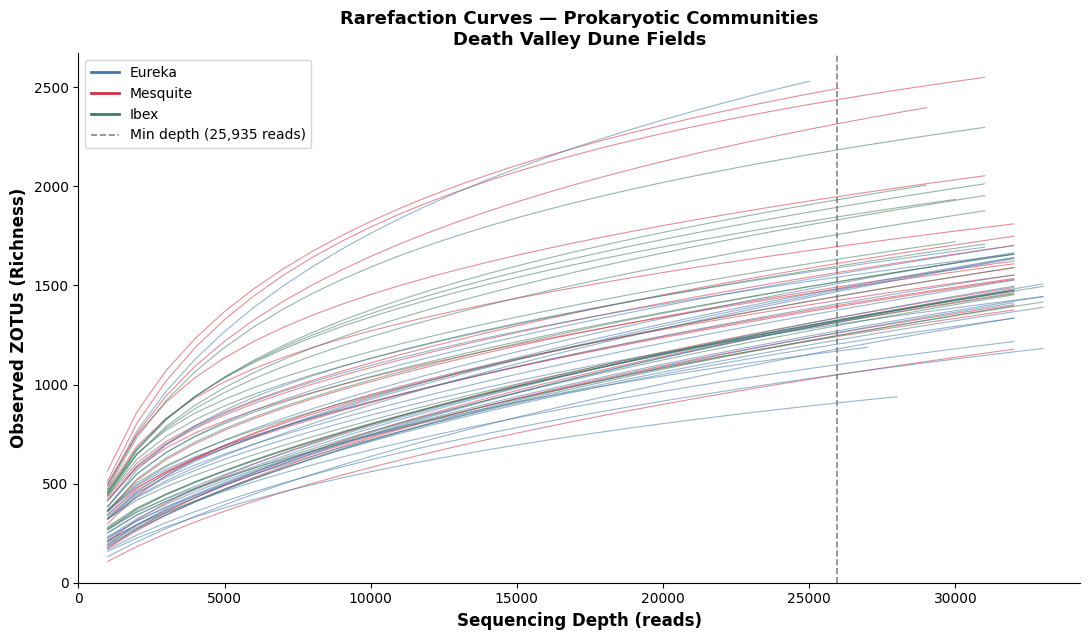

In [1]:
# ============================
# RAREFACTION CURVES -- PROKARYOTIC COMMUNITIES
# NOTE: rarefaction requires RAW READ COUNTS, not relative
# abundances. Point COUNT_PATH at the counts version of the
# decontaminated ZOTU table (integer reads per sample).
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

COUNT_PATH = "/content/zotutab_decontam_Final_withdepth.csv"  # <-- raw counts table

# ---- load (same 2-row header layout as the rel-abund file) ----
raw = pd.read_csv(COUNT_PATH, header=None)
df  = raw.iloc[2:].copy()
df.columns = raw.iloc[1]
df.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col = df.columns[0]
sample_cols = [c for c in df.columns
               if c not in tax_cols
               and c != zotu_col
               and "Blank" not in str(c)]

df[sample_cols] = df[sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df["Domain"] = df["Domain"].str.lower().str.strip()
df["Phylum"] = df["Phylum"].str.lower().str.strip()

# ---- keep bacteria + archaea only (same filter as PERMANOVA) ----
micro = df[
    df["Domain"].isin(["bacteria", "archaea"]) &
    (df["Phylum"] != "bacteria") &
    df["Phylum"].notna()
].copy()

counts = micro.set_index(zotu_col)[sample_cols].T  # samples x ZOTUs
counts = counts.round().astype(int)                # rarefaction needs integers

def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX"): return "Ibex"
    return "Other"

FIELD_COLORS = {"Eureka": "#4477AA",
                "Mesquite": "#CC3344",
                "Ibex": "#44795E"}

# ---- read-depth summary ----
depths_per_sample = counts.sum(axis=1)
print("Sample read depth summary:")
print(f"  Min:   {depths_per_sample.min()}")
print(f"  Max:   {depths_per_sample.max()}")
print(f"  Mean:  {depths_per_sample.mean():.0f}")
min_depth = int(depths_per_sample.min())

# ============================
# EXPECTED RAREFIED RICHNESS (analytic, Hurlbert 1971)
# E[S(d)] = sum over ZOTUs of  1 - C(N - n_i, d) / C(N, d)
# i.e. for each ZOTU, the probability that at least one of its
# reads appears in a random subsample of d reads. Analytic form
# gives smooth exact curves with no resampling noise; log-gamma
# is used so the binomial coefficients don't overflow.
# ============================
def rarefaction_curve(sample_counts, depths):
    n_i = sample_counts[sample_counts > 0].astype(float)  # reads per observed ZOTU
    N   = n_i.sum()                                       # total reads in sample
    out = []
    for d in depths:
        if d >= N:                       # can't subsample beyond the sample itself
            out.append(len(n_i))
            continue
        # log C(N - n_i, d) - log C(N, d), zotu-wise
        log_num = (gammaln(N - n_i + 1) - gammaln(d + 1)
                   - gammaln(N - n_i - d + 1))
        log_den = gammaln(N + 1) - gammaln(d + 1) - gammaln(N - d + 1)
        with np.errstate(invalid="ignore"):
            p_absent = np.exp(log_num - log_den)
        p_absent[N - n_i < d] = 0.0      # ZOTU with fewer "other" reads than d
                                         # MUST appear in the subsample
        out.append(float(np.sum(1.0 - p_absent)))
    return np.array(out)

# ---- evaluation depths: every 1000 reads up to the deepest sample ----
step   = 1000
depths = np.arange(step, depths_per_sample.max() + step, step)

# ============================
# PLOT
# ============================
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("white")

for s in sample_cols:
    fld = get_field(s)
    if fld == "Other":
        continue
    N_s   = depths_per_sample[s]
    d_use = depths[depths <= N_s]        # each curve stops at its own total depth
    if len(d_use) == 0:
        continue
    rich = rarefaction_curve(counts.loc[s].values, d_use)
    ax.plot(d_use, rich, color=FIELD_COLORS[fld],
            lw=0.8, alpha=0.55, zorder=3)

# dashed line at the shallowest sample = usable common rarefaction depth
ax.axvline(min_depth, color="#888888", lw=1.2, ls="--", zorder=2)

# legend: one proxy line per field + the min-depth marker
handles = [plt.Line2D([0], [0], color=c, lw=2, label=f)
           for f, c in FIELD_COLORS.items()]
handles.append(plt.Line2D([0], [0], color="#888888", lw=1.2, ls="--",
                          label=f"Min depth ({min_depth:,} reads)"))
ax.legend(handles=handles, fontsize=10, frameon=True,
          edgecolor="#cccccc", loc="upper left")

ax.set_xlabel("Sequencing Depth (reads)", fontsize=12, fontweight="bold")
ax.set_ylabel("Observed ZOTUs (Richness)", fontsize=12, fontweight="bold")
ax.set_title("Rarefaction Curves — Prokaryotic Communities\n"
             "Death Valley Dune Fields",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, depths_per_sample.max() * 1.03)
ax.set_ylim(0, None)
ax.tick_params(labelsize=10)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()